<a href="https://colab.research.google.com/github/iandrukhiv-cell/addressbook-python/blob/main/%D0%9A%D0%BE%D0%BF%D1%96%D1%8F_%D0%B7%D0%B0%D0%BF%D0%B8%D1%81%D0%BD%D0%B8%D0%BA%D0%B0_%22Module4Task_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Модуль 4. Часові ряди та сентимент-аналіз фінансових новин**


**Часові ряди та фінансові новини** — це два різні типи даних, які описують один і той самий ринковий процес з різних боків: часові ряди відображають **факт руху ціни**, а новини — **інформаційний контекст**, який може впливати на очікування учасників ринку. На етапі **збору та синхронізації** ключове — привести всі джерела до спільної часової осі: новини представлені за днями (Top1..Top25), а котирування (Bitcoin) мають різні значення цін (open, close тощо). Тому важливо правильно нормалізувати дату, обрати тип об’єднання (intersection/union), контролювати пропуски.

Попередня обробка часових рядів розглядалась в модулі 3.  

На етапі **попередньої обробки** текстових даних зазвичай необхідно перетворити текстовий потік у числові сигнали -  **сентимент-ознаки** (позитивність/негативність/нейтральність, інтенсивність, обсяг новин).

**Сентимент-ознаки** - це числові характеристики емоційного тону тексту, які перетворюють новини/пости/коментарі на дані для аналізу або моделей. Текст містить “настрій” (позитивний, негативний, нейтральний тощо), і цей настрій можна кодувати числами, щоб потім порівнювати з цінами, волатильністю чи будувати прогнози.

Протестувати обчислення сентимент-ознак можна із використанням моделі FinBert (https://huggingface.co/ProsusAI/finbert)

У **візуалізації та EDA** важливо порівнювати не лише графіки цін, а й **динаміку сентименту** та його зв’язок із доходностями/волатильністю: чи з’являються “вікна” підвищеної негативності перед просіданнями, чи працює ефект лише в кризові періоди, чи відрізняється реакція на різних активах.

## План на три заняття

1. Завантаження дані.

2. EDA.

3. Модель прогнозування








#**Завантаження даних**

**Вступ.** Завантажити таблиці даних, оцінити їх якість.

**Мета** — отримати **надійну “майстер-таблицю”** (master table) з коректним календарем: `Date` + новини + додаткові параметри. Така таблиця стане базою для подальшого EDA та побудови ознак без помилок у датах, дублікати чи пропусках.

**План**
1. Завантаження CSV з Kaggle та первинні перевірки якості (shape/dtypes/діапазони дат/пропуски).
2. Підготовка новин у форматі “один день → один текст” (агрегація заголовків за датою).
3. Валідація якості time-series (datetime-індекс, порядок, дублікати, пропущені дні) та вибір стратегії об’єднання (union/intersection).
4. Побудова master table та базове заповнення пропусків для подальших кроків.

**Результат заняття:** сформована master-таблиця (наприклад, `master_filled`), готова до описового аналізу та інженерії ознак.


Набір даних: https://www.kaggle.com/datasets/muhammedabdulazeem/bitcoin-price-prediction/


Багато в чому етапи завантаження та попередньої обробки даних нам вже знайомі з попередніх модулів. Залишилось тільки адаптувати ці підходи до комбінованих даних.

Підключення бібліотек для завантаження даних з Kaggle

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muhammedabdulazeem/bitcoin-price-prediction")

print("Path to dataset files:", path)

100%|██████████| 1.03M/1.03M [00:00<00:00, 29.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/muhammedabdulazeem/bitcoin-price-prediction/versions/3


In [ ]:
import os
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/root/.cache/kagglehub/datasets/muhammedabdulazeem/bitcoin-price-prediction/versions/3/btcNewsToPrice.csv
/root/.cache/kagglehub/datasets/muhammedabdulazeem/bitcoin-price-prediction/versions/3/btcNewsToPrice2.csv


In [ ]:
# Базові бібліотеки для аналізу даних
import os
from pathlib import Path
import numpy as np
import pandas as pd
import ast
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import re
from collections import Counter

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.graph_objects as go

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)




pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 60)

DATA_DIR = Path(path)
print("Files in dataset folder:")
for p in sorted(DATA_DIR.glob("*")):
    print(" -", p.name)


Files in dataset folder:
 - btcNewsToPrice.csv
 - btcNewsToPrice2.csv


## Завантаження даних

Датасет містить два файли з історичними даними та новинами:

* btcNewsToPrice.csv
* btcNewsToPrice2.csv

In [ ]:
df1   = pd.read_csv(DATA_DIR / "btcNewsToPrice.csv", parse_dates=["date"])
df2   = pd.read_csv(DATA_DIR / "btcNewsToPrice2.csv", parse_dates=["date"])


In [ ]:
print("djia   :", df1.shape, "|", df1["date"].min().date(), "→", df1["date"].max().date())
print("combo  :", df2.shape, "|", df2["date"].min().date(), "→", df2["date"].max().date())


display(df1.head(3))
display(df2.head(3))



djia   : (2169, 24) | 2015-07-01 → 2021-06-12
combo  : (2146, 43) | 2015-07-12 → 2021-06-03


,date,top_0,top_1,top_2,top_3,top_4,top_5,top_6,top_7,top_8,top_9,top_10,top_11,top_12,top_13,top_14,top_15,top_16,top_17,top_18,price,open,high,low
0,2015-07-01,Australia Plays Centralized Role in Banning Mobile Games...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,257.6,264.1,265.0,254.4
1,2015-07-02,Digital Technology to Exponentially Disrupt Business,Bitcoin Is A Better Way of Transferring Value Around The...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,254.9,257.6,261.3,253.1
2,2015-07-03,How Will Credit Work in a Bitcoin Economy?,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,255.4,254.9,256.7,252.4


,date,top_0,top_1,top_2,top_3,top_4,top_5,top_6,top_7,top_8,top_9,top_10,top_11,top_12,top_13,top_14,top_15,top_16,top_17,top_18,top_19,top_20,top_21,top_22,top_23,top_24,top_25,top_26,top_27,top_28,top_29,top_30,top_31,top_32,top_33,top_34,top_35,price,open,high,low,vol.,change %
0,2015-07-12,bitcoin the next logical step in the rise of unbanked mo...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,310.4,292.0,315.9,291.3,120.70K,6.33%
1,2015-07-13,bitgive foundation announces new initiatives at inside b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,290.4,310.4,310.9,276.9,146.85K,-6.47%
2,2015-07-14,keynote 2015 harnessing the distributed ledger bitcoin,the blockchain towards crypto sovereignty bitcoin,coinbase outage is a reminder to not store bitcoins on a...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,287.0,290.4,297.0,285.2,60.62K,-1.17%


Обидві таблиці (`btcNewsToPrice.csv` і `btcNewsToPrice2.csv`) мають **денну** структуру: кожен рядок відповідає окремій даті (`date`), містить набір новинних заголовків у колонках `top_0 … top_n` (частина з них `NaN`, бо кількість новин на день змінюється) та ринкові показники BTC (**OHLC**: `open`, `high`, `low` і поточну `price`). Перша таблиця охоплює **2015-07-01 → 2021-06-12** (2169 рядків, 24 колонки) і має **19 “слотів”** під заголовки (`top_0…top_18`), тоді як друга є розширеною версією з **2015-07-12 → 2021-06-03** (2146 рядків, 43 колонки): вона містить **36 слотів** для новин (`top_0…top_35`) та додаткові ринкові поля **`vol.`** (обсяг торгів) і **`change %`** (денна відносна зміна), тому потенційно дає більше текстового контексту й додаткові числові ознаки, але має трохи коротше часовe покриття.

Надалі будемо використовувати саме таблицю `btcNewsToPrice2.csv`

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2146 entries, 0 to 2145
Data columns (total 43 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      2146 non-null   datetime64[ns]
 1   top_0     2146 non-null   object        
 2   top_1     2119 non-null   object        
 3   top_2     2047 non-null   object        
 4   top_3     1849 non-null   object        
 5   top_4     1629 non-null   object        
 6   top_5     1382 non-null   object        
 7   top_6     1156 non-null   object        
 8   top_7     980 non-null    object        
 9   top_8     842 non-null    object        
 10  top_9     742 non-null    object        
 11  top_10    670 non-null    object        
 12  top_11    587 non-null    object        
 13  top_12    502 non-null    object        
 14  top_13    434 non-null    object        
 15  top_14    367 non-null    object        
 16  top_15    304 non-null    object        
 17  top_16    269 

## Базові перевірки якості

Перевіримо:
- пропуски в ключових полях
- дублікати дат у DJIA
- узгодженість діапазонів дат між таблицями


In [ ]:
def quick_quality_report(df, name, date_col="Date"):
    pass


In [ ]:
quick_quality_report(df2[["price", "open", "high", "low", "vol.", "change %"]], "Bitcoin table")


In [ ]:
quick_quality_report(df2, "News table")

Отже, всі пропуски знаходяться у колонках з новинами

## Підготовка новин “один день -> один текст”

Цей етап потрібен, щоб привести новинні дані до **єдиного зручного формату для аналізу**: *одна дата → один текстовий документ*. Тоді кожному торговому дню відповідає один “зведений” текст, який легко поєднати з ринковими рядами по `date` і використовувати в сентимент-аналізі або побудові текстових ознак.

In [ ]:
# функція зведення новин до однієї строки в день


In [ ]:
# результат застосування

,date,top_news
0,2015-07-12,bitcoin the next logical step in the rise of unbanked mo...
1,2015-07-13,bitgive foundation announces new initiatives at inside b...
2,2015-07-14,keynote 2015 harnessing the distributed ledger bitco...


## Об’єднання Bitcoin + новини в один датафрейм

Отримаємо “базову” таблицю за днями, де є:
- ціни Bitcoin
- агреговані новини


In [ ]:
# функції об'єднання новин та числових даних в один підготовленй датафрейм

In [ ]:
# результат застосування

,date,price,open,high,low,vol.,change %,top_news
0,2015-07-12,310.4,292.0,315.9,291.3,120.70K,6.33%,bitcoin the next logical step in the rise of unbanked mo...
1,2015-07-13,290.4,310.4,310.9,276.9,146.85K,-6.47%,bitgive foundation announces new initiatives at inside b...
2,2015-07-14,287.0,290.4,297.0,285.2,60.62K,-1.17%,keynote 2015 harnessing the distributed ledger bitco...
3,2015-07-15,283.4,287.0,292.9,283.2,59.58K,-1.23%,patrick byrne says will be able to replace wall street...
4,2015-07-16,276.6,283.4,290.8,273.3,121.32K,-2.41%,2015 q1 bitcoin investment trumps 2014 numbers bitcoi...


## Перевірка якості ринкових рядів

Після завантаження варто швидко перевірити:
- частку пропусків по кожній колонці,
- чи є дані на початку/в кінці періоду,


In [ ]:
# обчислення відсотка пропущених значень

In [ ]:
# результат застосування

,missing_%
date,0.0
price,0.0
open,0.0
high,0.0
low,0.0
vol.,0.0
change %,0.0
top_news,0.0


,non_null_count
date,2146
price,2146
open,2146
high,2146
low,2146
vol.,2146
change %,2146
top_news,2146


## Майстер-таблиця (DJIA + новини + всі ринки)

**Майстер-таблиця (master table)** — це зведена, узгоджена таблиця даних, у якій для кожного об’єкта аналізу (наприклад, клієнта, замовлення, дня) зібрані всі ключові ознаки з різних джерел і таблиць у форматі **“один рядок = один об’єкт”**. Вона слугує основною робочою основою для EDA, звітності та побудови моделей.


In [ ]:
# вигляд таблиці

,date,price,open,high,low,vol.,change %,top_news
0,2015-07-12,310.4,292.0,315.9,291.3,120.70K,6.33%,bitcoin the next logical step in the rise of unbanked mo...
1,2015-07-13,290.4,310.4,310.9,276.9,146.85K,-6.47%,bitgive foundation announces new initiatives at inside b...
2,2015-07-14,287.0,290.4,297.0,285.2,60.62K,-1.17%,keynote 2015 harnessing the distributed ledger bitco...
3,2015-07-15,283.4,287.0,292.9,283.2,59.58K,-1.23%,patrick byrne says will be able to replace wall street...
4,2015-07-16,276.6,283.4,290.8,273.3,121.32K,-2.41%,2015 q1 bitcoin investment trumps 2014 numbers bitcoi...
...,...,...,...,...,...,...,...,...
2141,2021-05-30,35652.8,34589.3,36388.6,33441.0,104.18K,3.09%,after the installation of microbt whatsminers ez blockc...
2142,2021-05-31,37298.6,35644.0,37480.7,34213.2,131.70K,4.62%,brazil is one of the pioneers of cdbc s study and resear...
2143,2021-06-01,36687.6,37294.3,37850.3,35742.7,113.48K,-1.64%,our maiden sto listing on the dbs digital exchange is ...
2144,2021-06-02,37555.8,36687.7,38199.9,35981.1,96.89K,2.37%,expanding cryptocurrency analysis to find and pursue cr...


# **EDA**

**Вступ.** Ми маємо **узгоджену master-таблицю** з часовими рядами та новинним контекстом. Тепер переходимо до **описового аналізу (EDA)**: досліджуємо масштаби й динаміку активів, розглядаємо доходності та волатильність, перевіряємо кореляції й їхню змінність у часі, а також робимо елементарних аналіз текстів.

**Мета** — отримати **інсайти про структуру даних**: тренди, мінливість, сезонні ефекти, взаємозв’язки між активами та потенційні режими, щоб зрозуміти, які перетворення і які ознаки мають сенс для подальшого моделювання.

**План**
1. Підготовка даних для візуалізацій.
2. Масштабування/трансформації.
3. Аналіз зв’язків: кореляційна heatmap, rolling correlation (кореляція в часі).

**Результат заняття:** набір EDA-графіків і коротких висновків про тренди, волатильність, кореляції, сезонність і режими, які підказують напрями для інженерії ознак і моделей.


## Масштабування та трансформації даних (normalization / standardization / log)

У фінансових часових рядах часто застосовують:

- **Нормалізацію (Min-Max)**: переводить значення в інтервал [0, 1]  
- **Стандартизацію (Z-score)**: робить середнє 0, стандартне відхилення 1  
- **Логарифмування**: стабілізує дисперсію та “стискає” великі значення (актуально для рядів з великими розмахами)


In [ ]:
# функції масштабування

## Перетворення типів


Колонка `vol.` має символьні позначення тисяч. Потрібно перетворити ці дані на коректні числові.

In [ ]:
df2_daily["vol."]

,vol.
0,120.70K
1,146.85K
2,60.62K
3,59.58K
4,121.32K
...,...
2141,104.18K
2142,131.70K
2143,113.48K
2144,96.89K


In [ ]:
# функції перетворення на числові дані

In [ ]:
df2_daily["vol_num"] = parse_vol_series(df2_daily["vol."])

## Масштабування (MinMaxScaler)

Застосуємо MinMax scaling до всіх числових колонок.


In [ ]:
scale_cols = ["price", "open", "high", "low", "vol_num"]

In [ ]:
df_scaled, mm_scaler = minmax_scale(df2_daily, scale_cols)

print("df_scaled shape:", df_scaled.shape)
display(df_scaled.head())


df_scaled shape: (2146, 9)


,date,price,open,high,low,vol.,change %,top_news,vol_num
0,2015-07-12,0.001563,0.001273,0.001383,0.001535,120.70K,6.33%,bitcoin the next logical step in the rise of unbanked mo...,0.005840
1,2015-07-13,0.001247,0.001563,0.001306,0.001303,146.85K,-6.47%,bitgive foundation announces new initiatives at inside b...,0.007131
2,2015-07-14,0.001194,0.001247,0.001091,0.001437,60.62K,-1.17%,keynote 2015 harnessing the distributed ledger bitco...,0.002874
3,2015-07-15,0.001137,0.001194,0.001027,0.001405,59.58K,-1.23%,patrick byrne says will be able to replace wall street...,0.002823
4,2015-07-16,0.001030,0.001137,0.000995,0.001245,121.32K,-2.41%,2015 q1 bitcoin investment trumps 2014 numbers bitcoi...,0.005870


## Візуалізація: усі часові ряди на одному графіку

Оскільки різні інструменти мають різні масштаби, зручно візуалізувати **нормалізовані (MinMax) ряди**.


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# plot_df має містити: Date, Label, та всі scale_cols (MinMax)
plot_df = df_scaled[["date", "price", "open", "high", "low", "vol_num", "change %"]].copy()

scale_cols = ["price", "open", "high", "low"]


In [ ]:
#функції візуалізації

## Обробка текстів новин

## Токенізація новин “за кожний день”

Мета: для кожної дати отримати список токенів (слів).
Зазвичай робимо:
- нижній регістр
- залишаємо лише латинські слова (a-z)
- відкидаємо дуже короткі токени (наприклад, довжина < 2)


In [ ]:
# функції обробки текстових даних

## Список стоп-слів для англійської мови

Стоп-слова — це дуже часті службові слова (the, and, of...), які рідко несуть зміст.
Ми сформуємо набір stopwords (set) для швидкої перевірки входження.

Підхід:
- беремо стандартний список NLTK
- додаємо кілька “технічних” слів, які часто трапляються в новинах (наприклад, `amp`, `rt`)


In [ ]:
# функція завантаження списку стоп-слів

## Видалення стоп-слів з токенів

На цьому кроці ми фільтруємо токени:
- прибираємо слова зі stopwords
- (опційно) прибираємо чисто числові токени (в нашій токенізації їх і так нема)
Результат збережемо у новій колонці `tokens_clean`.


In [ ]:
# функція видалення стоп-слів

## Датафрейм з топ-100 токенів

Мета: зібрати частоти токенів (після очищення), відсортувати та зберегти 100 найчастіших.
Отримаємо таблицю:

token | count


In [ ]:
# Функція, яка обчислює частоти токенів по всіх днях і повертає DataFrame з топ-N

## Гістограма топ-10 найчастіших токенів

Мета: швидко візуально побачити, які слова домінують у корпусі новин (після видалення стоп-слів).
Будуємо bar chart для перших 10 токенів з таблиці top-100.


In [ ]:
# функція побудови гістограми топ-100 найчастіших токенів (слів)

## Хмара слів (Word Cloud)

Хмара слів — це наочна візуалізація частот: чим частіше токен, тим він більший на зображенні.
Для цього використаємо бібліотеку `wordcloud` і передамо їй частоти токенів.


In [ ]:
# функція побудови хмари слів

## Приклад обробки

In [ ]:
# приклад застосування розроблених функцій обробки текстових даних

# Прогнозування значень одного часового ряду

## Задача прогнозування

**Вступ**. Прогнозування одного часового ряду за допомогою іншого є типовою задачею аналізу даних, коли доступні дві синхронізовані послідовності спостережень, що описують пов’язані процеси. У загальному випадку маємо дві величини, виміряні в однакові моменти часу: цільовий ряд $y_t$ та пояснювальний ряд $x_t$. Мета полягає в тому, щоб оцінити, наскільки зміни $x_t$ можуть пояснювати або передбачати зміни $y_t$, і побудувати просту інтерпретовану модель залежності між ними.

Найбазовішим підходом є **проста лінійна регресія**, яка припускає, що між рядами існує приблизно лінійний зв’язок:
$$
y_t = a + bx_t + \varepsilon_t,
$$
де $a$ — вільний член (систематичний зсув), $b$ — коефіцієнт чутливості цільового ряду до змін пояснювального, а $\varepsilon_t$ — похибка, що акумулює невраховані фактори та випадкові коливання. Перевага цього підходу полягає в простоті, прозорості та можливості прямої інтерпретації параметрів: знак і величина $b$ описують напрям і силу співруху між процесами.

Для часових рядів важливо коректно організувати підготовку даних. Часто замість “рівнів” $x_t, y_t$ використовують **ознаки** (наприклад, різниці або доходності), оскільки тренд і різні масштаби можуть створювати хибне враження сильного зв’язку. Також принципово застосовувати **розбиття за часом**: модель навчається на минулому відрізку (train), а оцінюється на майбутньому (test). Це забезпечує прогнозну інтерпретацію результатів і запобігає витоку інформації з майбутнього, який виникає при випадковому перемішуванні спостережень.

Оцінювання якості моделі зазвичай включає метрики похибки (MAE, RMSE) та показники пояснювальної здатності (наприклад, (R^2)), а також діагностику залишків для перевірки систематичних помилок. Хоча проста лінійна регресія не враховує всі складності часових процесів (автокореляцію, зміну режимів, нелінійності), вона є корисним **базовим орієнтиром**: дозволяє швидко встановити наявність зв’язку, оцінити його стабільність у часі та сформувати відправну точку для більш складних моделей прогнозування.

**Мета** — побудувати **базову (baseline) модель** і отримати інтерпретований результат: коефіцієнт чутливості (beta-стиль), якість прогнозу на test та діагностика залишків.


**План**
1. Підготовка даних: з одного часового ряду отримати цільову змінну та ознаки.
2. Розбиття за часом на train/test (без leakage).
3. Візуальна перевірка зв’язку (lmplot на train + точки test).
4. Навчання лінійної регресії, прогноз на test та метрики (MAE/RMSE/R²).
5. Діагностика залишків і стабільність зв’язку в часі (rolling beta).

**Результат заняття:** baseline-модель прогнозування та набір висновків про силу/стабільність зв’язку, який можна використовувати як відправну точку для складніших моделей.




## Підготовка даних: ознаки та цільова змінна



Функція `create_univariate_dataset(series, window_size, forecast_horizon)` реалізує класичне перетворення **одновимірного часового ряду** на навчальний набір для **supervised learning** за принципом *sliding window* (ковзного вікна).

Замість “одного довгого” ряду створюється багато пар **(вхід → ціль)**, де вхід `X` — це фрагмент з `window_size` послідовних минулих значень, а ціль `y` — це наступні `forecast_horizon` значень, які модель має передбачити. Цикл перебирає всі можливі позиції вікна `i` так, щоб і вхідне вікно, і майбутній відрізок цілі повністю містилися в межах ряду; саме тому верхня межа `len(series) - window_size - forecast_horizon + 1`. У підсумку `X` має форму `(N, window_size)`, а `y` — `(N, forecast_horizon)`, де `N` — кількість згенерованих прикладів. Таким чином, задача прогнозування часового ряду зводиться до стандартної задачі регресії: модель вчиться відображати історичний контекст фіксованої довжини у вектор майбутніх значень (multi-step forecasting) — без рекурсивного “крок за кроком” передбачення.


In [ ]:
def create_univariate_dataset(series, window_size, forecast_horizon):
    """
    Створює univariate набір для прогнозування відразу forecast_horizon значень.
    """
    X, y = [], []
    for i in range(len(series) - window_size - forecast_horizon + 1):
        X.append(series[i:i + window_size])
        y.append(series[i + window_size : i + window_size + forecast_horizon])
    return np.array(X), np.array(y)

In [ ]:
X_uni, y_uni = create_univariate_dataset(df2_daily["price"].values, window_size=1, forecast_horizon=1)

print("\n Univariate shape:", X_uni.shape, y_uni.shape)



 Univariate shape: (2145, 1) (2145, 1)


In [ ]:
y_uni.flatten()

array([  290.4,   287. ,   283.4, ..., 36687.6, 37555.8, 38372.7])

In [ ]:
X_uni.flatten()

array([  310.4,   290.4,   287. , ..., 37298.6, 36687.6, 37555.8])

In [ ]:
df_pair = pd.DataFrame({'X_uni':X_uni.flatten(), 'y_uni':y_uni.flatten()})

In [ ]:
df_pair

,X_uni,y_uni
0,310.4,290.4
1,290.4,287.0
2,287.0,283.4
3,283.4,276.6
4,276.6,279.6
...,...,...
2140,34584.6,35652.8
2141,35652.8,37298.6
2142,37298.6,36687.6
2143,36687.6,37555.8


In [ ]:
df2_model = pd.concat([df2_daily, df_pair],axis=1)

In [ ]:
df2_model

,date,price,open,high,low,vol.,change %,top_news,vol_num,X_uni,y_uni
0,2015-07-12,310.4,292.0,315.9,291.3,120.70K,6.33%,bitcoin the next logical step in the rise of unbanked mo...,120700.0,310.4,290.4
1,2015-07-13,290.4,310.4,310.9,276.9,146.85K,-6.47%,bitgive foundation announces new initiatives at inside b...,146850.0,290.4,287.0
2,2015-07-14,287.0,290.4,297.0,285.2,60.62K,-1.17%,keynote 2015 harnessing the distributed ledger bitco...,60620.0,287.0,283.4
3,2015-07-15,283.4,287.0,292.9,283.2,59.58K,-1.23%,patrick byrne says will be able to replace wall street...,59580.0,283.4,276.6
4,2015-07-16,276.6,283.4,290.8,273.3,121.32K,-2.41%,2015 q1 bitcoin investment trumps 2014 numbers bitcoi...,121320.0,276.6,279.6
...,...,...,...,...,...,...,...,...,...,...,...
2141,2021-05-30,35652.8,34589.3,36388.6,33441.0,104.18K,3.09%,after the installation of microbt whatsminers ez blockc...,104180.0,35652.8,37298.6
2142,2021-05-31,37298.6,35644.0,37480.7,34213.2,131.70K,4.62%,brazil is one of the pioneers of cdbc s study and resear...,131700.0,37298.6,36687.6
2143,2021-06-01,36687.6,37294.3,37850.3,35742.7,113.48K,-1.64%,our maiden sto listing on the dbs digital exchange is ...,113480.0,36687.6,37555.8
2144,2021-06-02,37555.8,36687.7,38199.9,35981.1,96.89K,2.37%,expanding cryptocurrency analysis to find and pursue cr...,96890.0,37555.8,38372.7


## Time split (train/test)

Наступний блок коду робить **розбиття часового ряду на train/test у правильному хронологічному порядку** (без перемішування).

* `train_frac = 0.8` — задаємо частку даних для навчання: **80%**.
* `cut = int(len(df_pair) * train_frac)` — рахуємо індекс “розрізу”, тобто скільки перших рядків піде в train.
* `train = df_pair.iloc[:cut].copy()` — беремо **перші 80%** спостережень (минуле) як навчальну вибірку.
* `test  = df_pair.iloc[cut:].copy()` — беремо **останні 20%** (майбутнє) як тестову вибірку.

Це робиться, щоб оцінювати модель **так, як вона працюватиме в реальності**: ми навчаємось на минулих даних (train) і перевіряємо якість на майбутніх (test). Для часових рядів випадкове перемішування дає **витік інформації** (у train можуть потрапити “майбутні” спостереження) і штучно завищує метрики. Time split забезпечує чесну перевірку, показує здатність моделі узагальнювати в часі та допомагає помітити зміну режимів ринку, коли зв’язки між змінними з часом змінюються.




In [ ]:
# розділення даних на набір для тренування та тестування

## Візуалізація лінійної моделі

У наступнму блоку будується **діаграма розсіювання доходностей** і показує, наскільки добре **лінійна залежність** DJIA↔S&P500 описує дані.

* `sns.lmplot(...)` будує scatter для **train** і одночасно додає **лінію лінійної регресії**, підігнану **лише на train**:

  * `x="r_sp500"` — доходність S&P500 (пояснювальна змінна),
  * `y="r_djia"` — доходність DJIA (ціль/залежна змінна),

У підсумку цей графік допомагає швидко оцінити: **наскільки зв’язок лінійний**, чи є **зміщення/асиметрія** (наприклад, різна поведінка на великих рухах), і чи **узгоджується test із train** (стабільність зв’язку в часі).



In [ ]:
# візуалізація лінійної моделі засобами sns.lmplot

## Прогноз і метрики (на test)




In [ ]:
# обчислення прогнозу лінійної моделі та метрик якості

## Візуалізація "факт vs прогноз" у часі (Plotly)

Цей графік показує:
- чи відтворює модель амплітуду рухів DJIA,
- чи є періоди, де помилка зростає (можлива зміна режиму або нестабільність beta).


In [ ]:
# побудова графіку оригінальних даних та прогнозованих

## Діагностика залишків (Seaborn)

Наступним етапом необхідно зробити діагностику залишків моделі на тестовій вибірці: спочатку обчислюються залишки як різницю **true − predicted**, а далі будуємо три графіки.

Гістограма з KDE показує, чи розподіл помилок приблизно симетричний і чи немає зсуву відносно нуля.

Графік **residuals vs predicted** перевіряє, чи помилка не залежить від величини прогнозу (чи немає тренду/кривизни та чи не зростає розкид для великих рухів).

Графік **y_true vs y_pred** показує, наскільки прогнози узгоджуються з реальними значеннями: чим щільніше точки вздовж діагоналі, тим краща якість апроксимації.


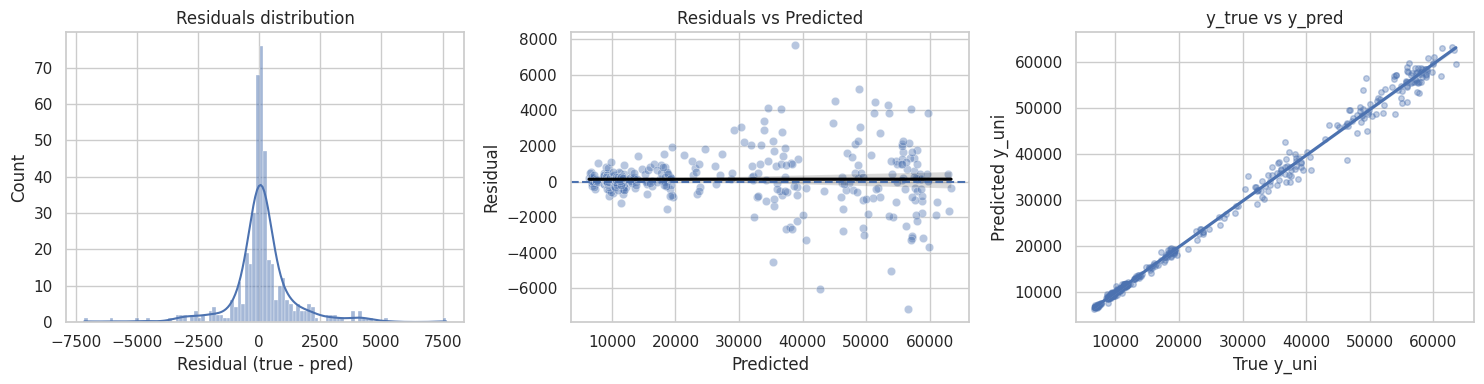

In [ ]:
# функції діагностики залишків моделі засобами regplot